In [ ]:
!pip install tensorflow scikit-learn seaborn matplotlib pandas numpy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from zipfile import ZipFile

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import GRU

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

print(tf.__version__)

2.20.0


In [ ]:
from google.colab import files

# Ensure the files are saved to the current directory
forecast.to_csv('AQI_30_Days_Forecast.csv', index=False)
comparison.to_csv('Model_Comparison.csv', index=False)

# Trigger the download
files.download('AQI_30_Days_Forecast.csv')
files.download('Model_Comparison.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = pd.read_csv('/content/city_day.csv')

In [ ]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [ ]:
df.shape

(29531, 16)

In [ ]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
df = df.sort_values("Date")

In [ ]:
df = df[["Date","City","AQI","PM2.5","PM10","NO","NO2","NOx","NH3","CO","SO2","O3"]]

In [ ]:
df = df.fillna(method="ffill")
df = df.fillna(method="bfill")

/tmp/ipykernel_424/4232275779.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")
/tmp/ipykernel_424/4232275779.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="bfill")


In [ ]:
df.isnull().sum()

,0
Date,0
City,0
AQI,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0


In [ ]:
df.to_csv("Clean_AQI_Dataset.csv",index=False)

In [ ]:
df.to_csv("Clean_AQI_Dataset.csv",index=False)

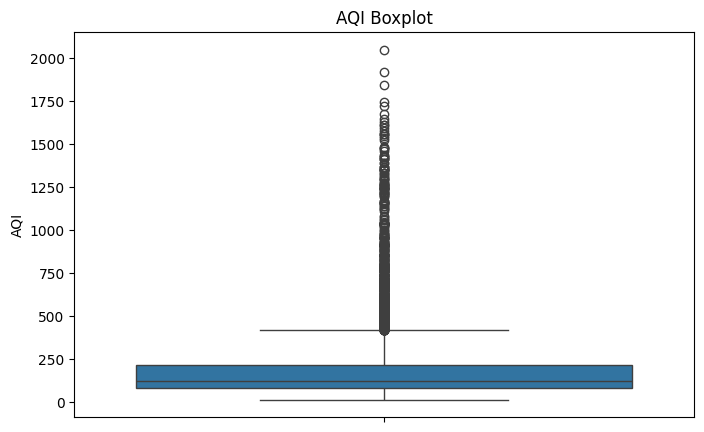

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["AQI"])
plt.title("AQI Boxplot")
plt.show()

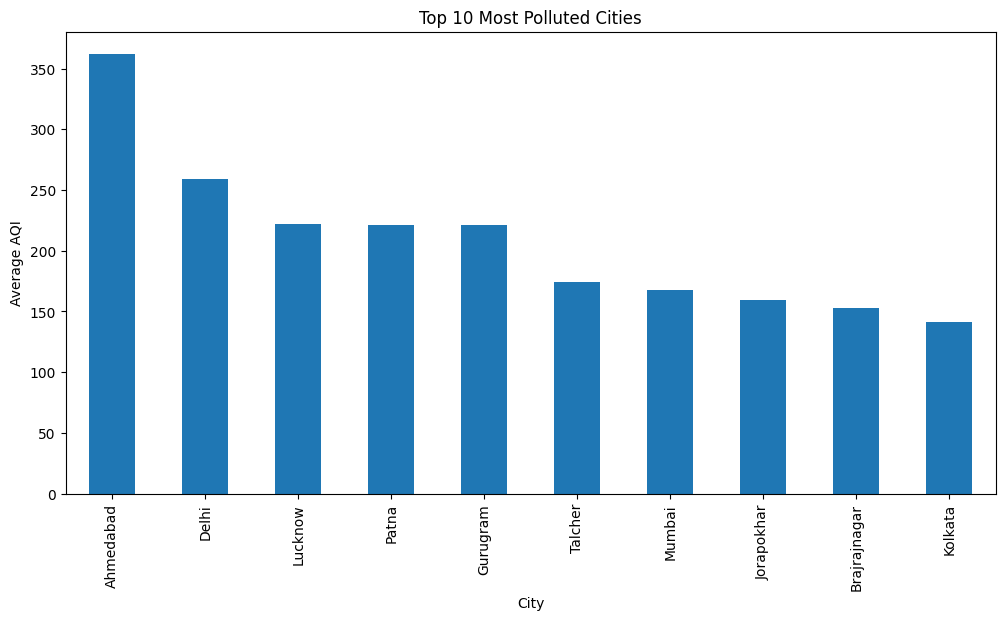

In [ ]:
top_city = df.groupby("City")["AQI"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_city.plot(kind="bar")
plt.title("Top 10 Most Polluted Cities")
plt.ylabel("Average AQI")
plt.show()

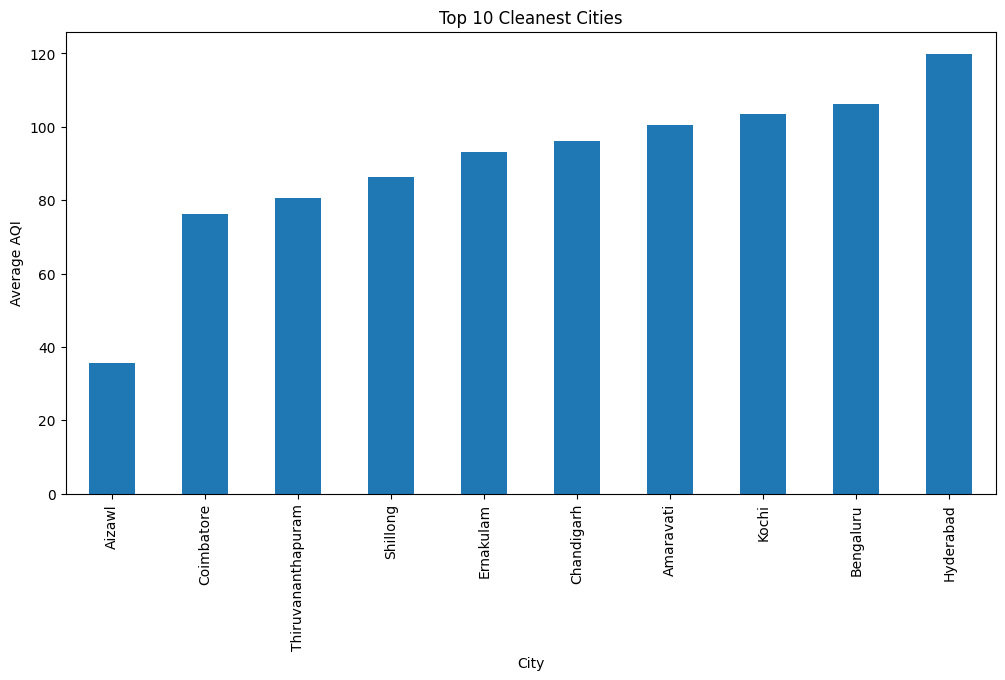

In [ ]:
clean_city = df.groupby("City")["AQI"].mean().sort_values().head(10)

plt.figure(figsize=(12,6))
clean_city.plot(kind="bar")
plt.title("Top 10 Cleanest Cities")
plt.ylabel("Average AQI")
plt.show()

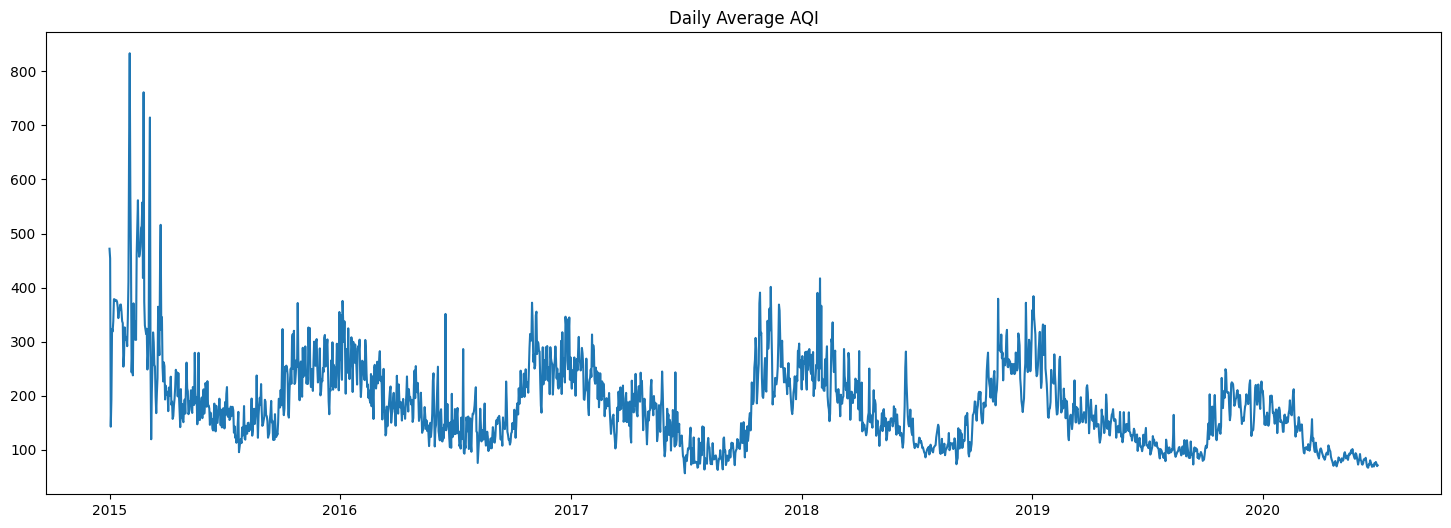

In [ ]:
daily_aqi = df.groupby("Date")["AQI"].mean()

plt.figure(figsize=(18,6))
plt.plot(daily_aqi)
plt.title("Daily Average AQI")
plt.show()

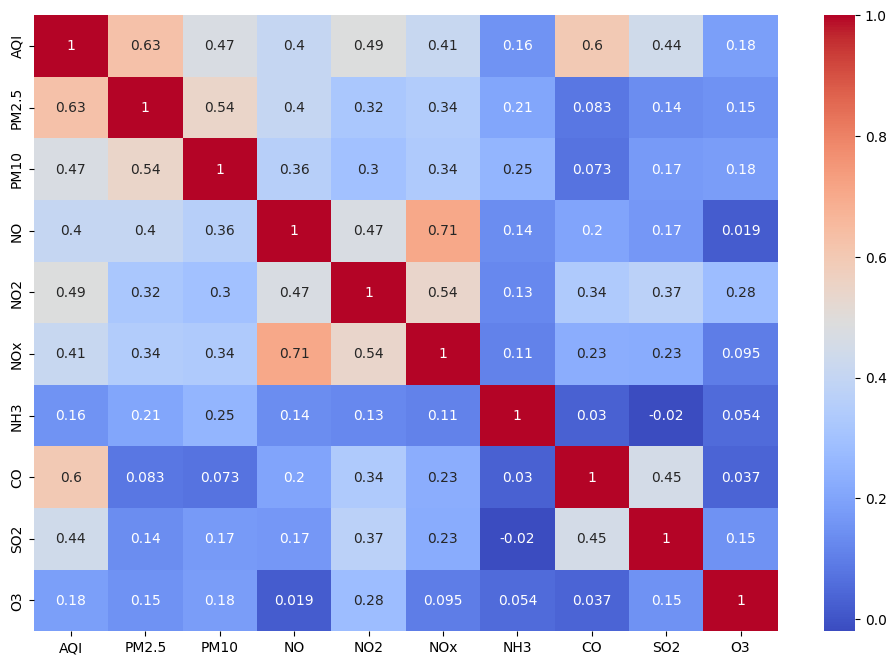

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()

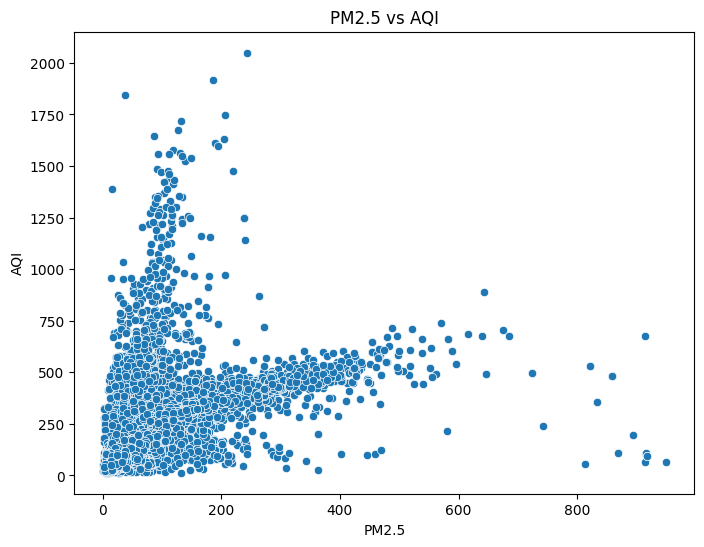

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="PM2.5", y="AQI")
plt.title("PM2.5 vs AQI")
plt.show()

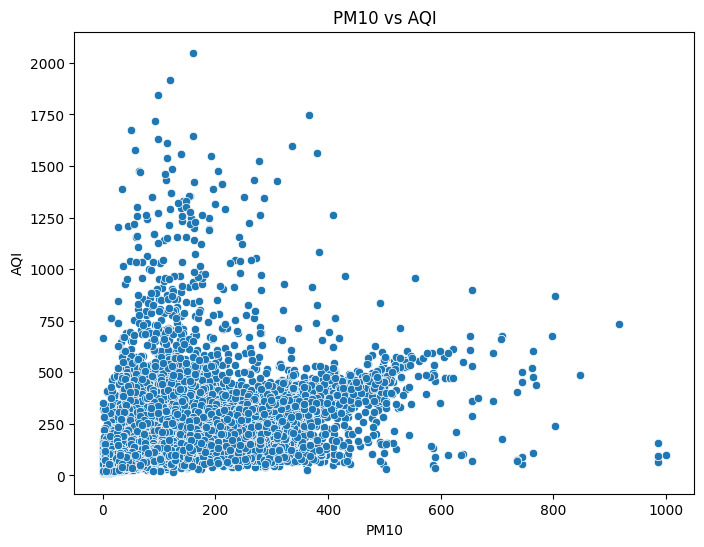

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="PM10", y="AQI")
plt.title("PM10 vs AQI")
plt.show()

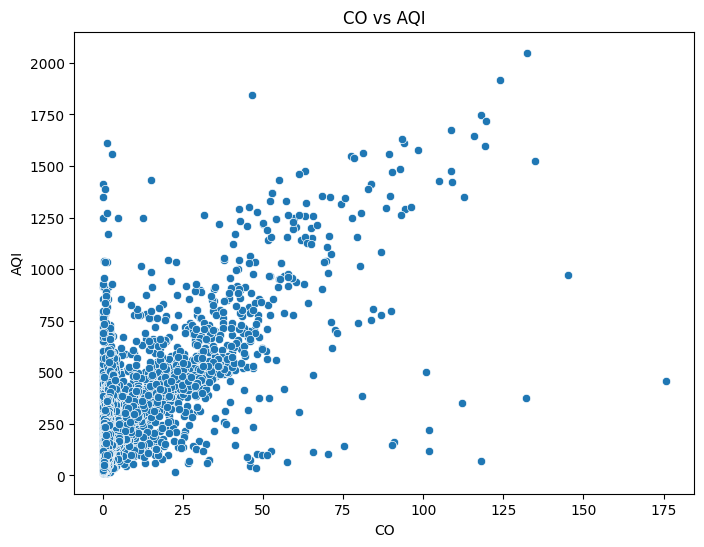

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="CO", y="AQI")
plt.title("CO vs AQI")
plt.show()

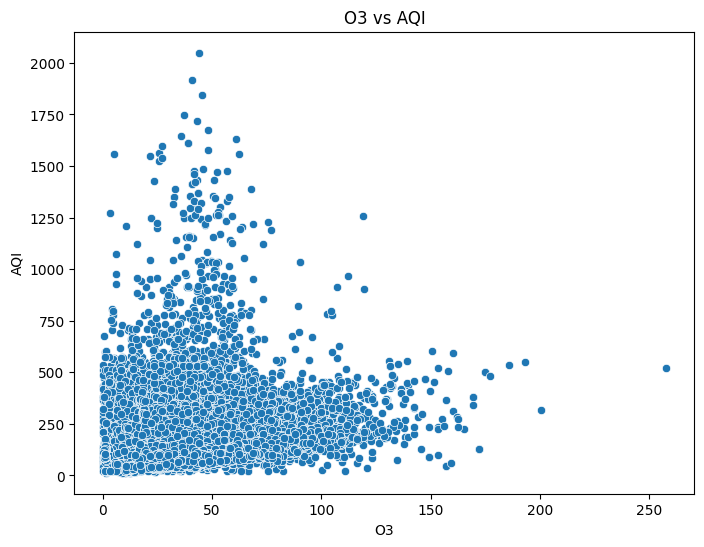

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="O3", y="AQI")
plt.title("O3 vs AQI")
plt.show()

In [ ]:
city_df = df[df["City"] == "Delhi"].copy()

city_df = city_df.sort_values("Date")

city_df = city_df[["Date","AQI"]]

city_df.head()

,Date,AQI
10229,2015-01-01,472.0
10230,2015-01-02,454.0
10231,2015-01-03,143.0
10232,2015-01-04,319.0
10233,2015-01-05,325.0


In [ ]:
city_df.set_index("Date", inplace=True)

city_df.head()

,AQI
Date,
2015-01-01,472.0
2015-01-02,454.0
2015-01-03,143.0
2015-01-04,319.0
2015-01-05,325.0


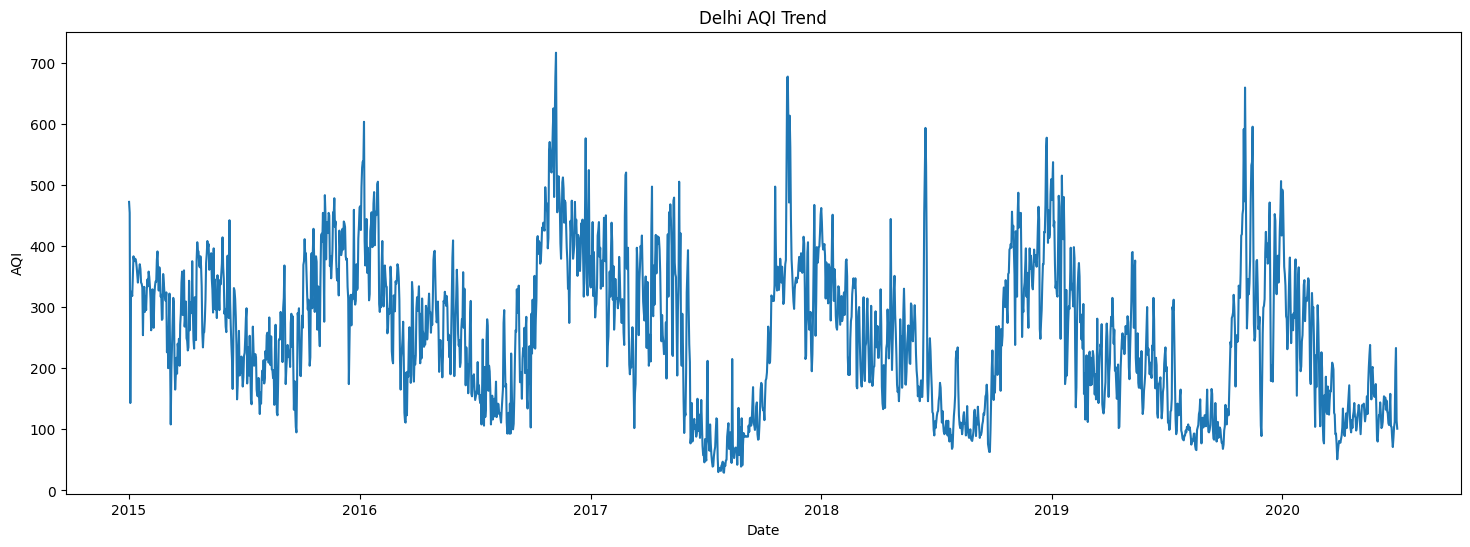

In [ ]:
plt.figure(figsize=(18,6))

plt.plot(city_df["AQI"])

plt.title("Delhi AQI Trend")

plt.xlabel("Date")

plt.ylabel("AQI")

plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(city_df)

In [ ]:
def create_sequences(data, sequence_length):

    X = []

    y = []

    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])

        y.append(data[i])

    return np.array(X), np.array(y)

In [ ]:
sequence_length = 30

X, y = create_sequences(scaled_data, sequence_length)

In [ ]:
print(X.shape)

print(y.shape)

(1979, 30, 1)
(1979, 1)


In [ ]:
split_index = int(len(X)*0.8)

X_train = X[:split_index]

X_test = X[split_index:]

y_train = y[:split_index]

y_test = y[split_index:]

In [ ]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(1583, 30, 1)
(396, 30, 1)
(1583, 1)
(396, 1)


In [ ]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(1583, 30, 1)
(396, 30, 1)
(1583, 1)
(396, 1)


In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [ ]:
checkpoint = ModelCheckpoint(
    "best_lstm.keras",
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
lstm_model = Sequential()

lstm_model.add(LSTM(
    128,
    return_sequences=True,
    input_shape=(X_train.shape[1], X_train.shape[2])
))

lstm_model.add(Dropout(0.3))

lstm_model.add(LSTM(
    64
))

lstm_model.add(Dropout(0.3))

lstm_model.add(Dense(32, activation="relu"))

lstm_model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

In [ ]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0266 - mae: 0.1219 - val_loss: 0.0114 - val_mae: 0.0824
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0129 - mae: 0.0885 - val_loss: 0.0123 - val_mae: 0.0861
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0135 - mae: 0.0909 - val_loss: 0.0102 - val_mae: 0.0733
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0118 - mae: 0.0850 - val_loss: 0.0098 - val_mae: 0.0712
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0115 - mae: 0.0835 - val_loss: 0.0094 - val_mae: 0.0705
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0109 - mae: 0.0807 - val_loss: 0.0092 - val_mae: 0.0710
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0111 - mae: 0.0815 - val_loss: 0.0088 - val_mae: 0.0676
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0105 - mae: 0.0797 - val_loss: 0.0102 - val_mae: 0.0796
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - lo

In [ ]:
best_model = tf.keras.models.load_model("best_lstm.keras")

In [ ]:
prediction = best_model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [ ]:
prediction = scaler.inverse_transform(prediction)

y_actual = scaler.inverse_transform(y_test)

In [ ]:
mae = mean_absolute_error(y_actual, prediction)

mse = mean_squared_error(y_actual, prediction)

rmse = np.sqrt(mse)

r2 = r2_score(y_actual, prediction)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 32.049040804005635
MSE : 1964.570653750072
RMSE : 44.32347745552093
R2 Score : 0.8490537943307104


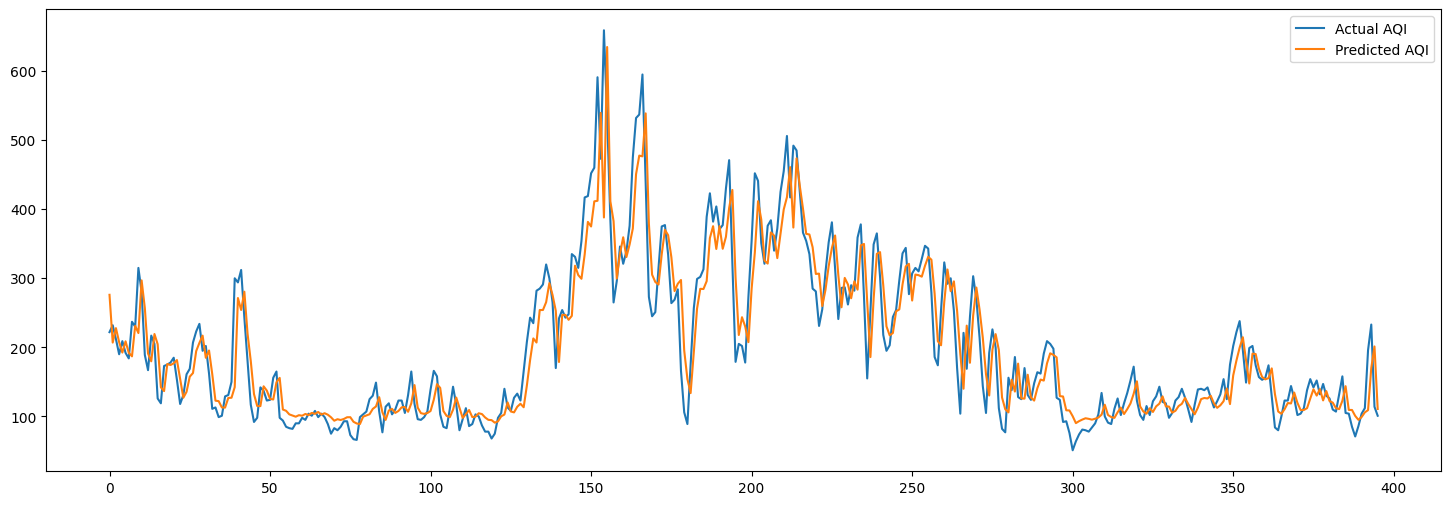

In [ ]:
plt.figure(figsize=(18,6))

plt.plot(y_actual, label="Actual AQI")

plt.plot(prediction, label="Predicted AQI")

plt.legend()

plt.show()

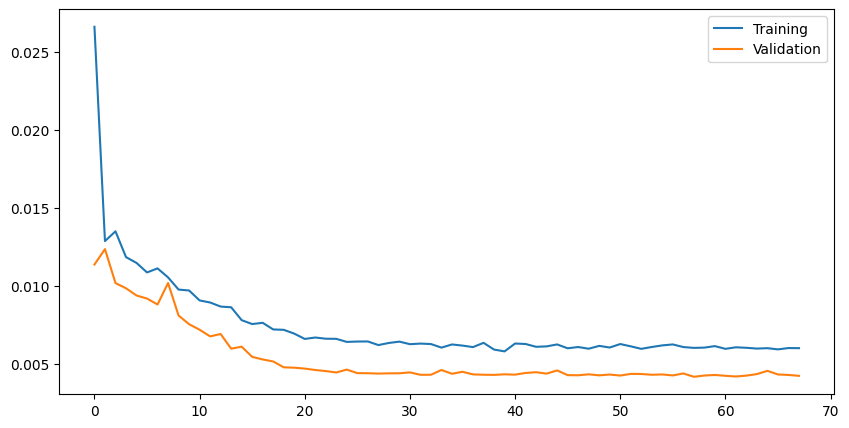

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Training","Validation"])

plt.show()

In [ ]:
best_model.save("AQI_LSTM_Final.keras")

In [ ]:
from tensorflow.keras.layers import Bidirectional

In [ ]:
cnn_lstm = Sequential()

cnn_lstm.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu",
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

cnn_lstm.add(MaxPooling1D(pool_size=2))

cnn_lstm.add(LSTM(64))

cnn_lstm.add(Dropout(0.3))

cnn_lstm.add(Dense(32, activation="relu"))

cnn_lstm.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_lstm.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

In [ ]:
cnn_history = cnn_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0313 - mae: 0.1314 - val_loss: 0.0110 - val_mae: 0.0791
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0126 - mae: 0.0877 - val_loss: 0.0102 - val_mae: 0.0731
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0119 - mae: 0.0839 - val_loss: 0.0099 - val_mae: 0.0731
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0118 - mae: 0.0837 - val_loss: 0.0095 - val_mae: 0.0720
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0114 - mae: 0.0824 - val_loss: 0.0090 - val_mae: 0.0691
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0103 - mae: 0.0786 - val_loss: 0.0084 - val_mae: 0.0659
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0097 - mae: 0.0767 - val_loss: 0.0083 - val_mae: 0.0666
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0096 - mae: 0.0764 - val_loss: 0.0075 - val_mae: 0.0620
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0

In [ ]:
cnn_prediction = cnn_lstm.predict(X_test)

cnn_prediction = scaler.inverse_transform(cnn_prediction)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [ ]:
cnn_mae = mean_absolute_error(y_actual, cnn_prediction)

cnn_mse = mean_squared_error(y_actual, cnn_prediction)

cnn_rmse = np.sqrt(cnn_mse)

cnn_r2 = r2_score(y_actual, cnn_prediction)

print("MAE :", cnn_mae)

print("RMSE :", cnn_rmse)

print("R2 :", cnn_r2)

MAE : 54.349572037205554
RMSE : 72.10858839993811
R2 : 0.6004891890421589


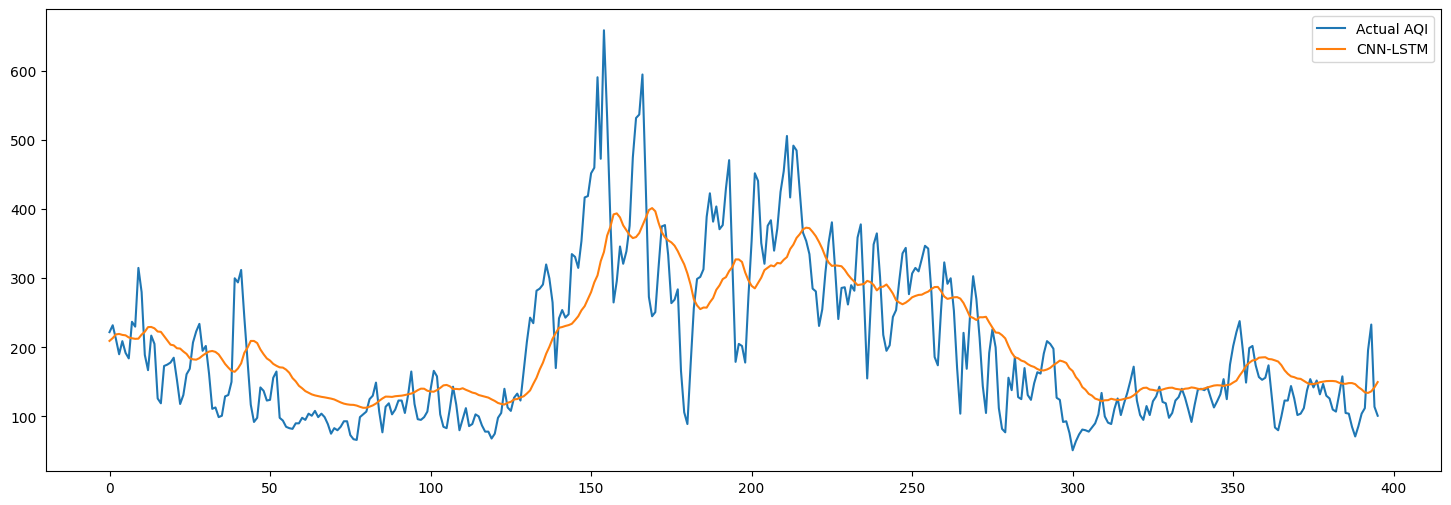

In [ ]:
plt.figure(figsize=(18,6))

plt.plot(y_actual, label="Actual AQI")

plt.plot(cnn_prediction, label="CNN-LSTM")

plt.legend()

plt.show()

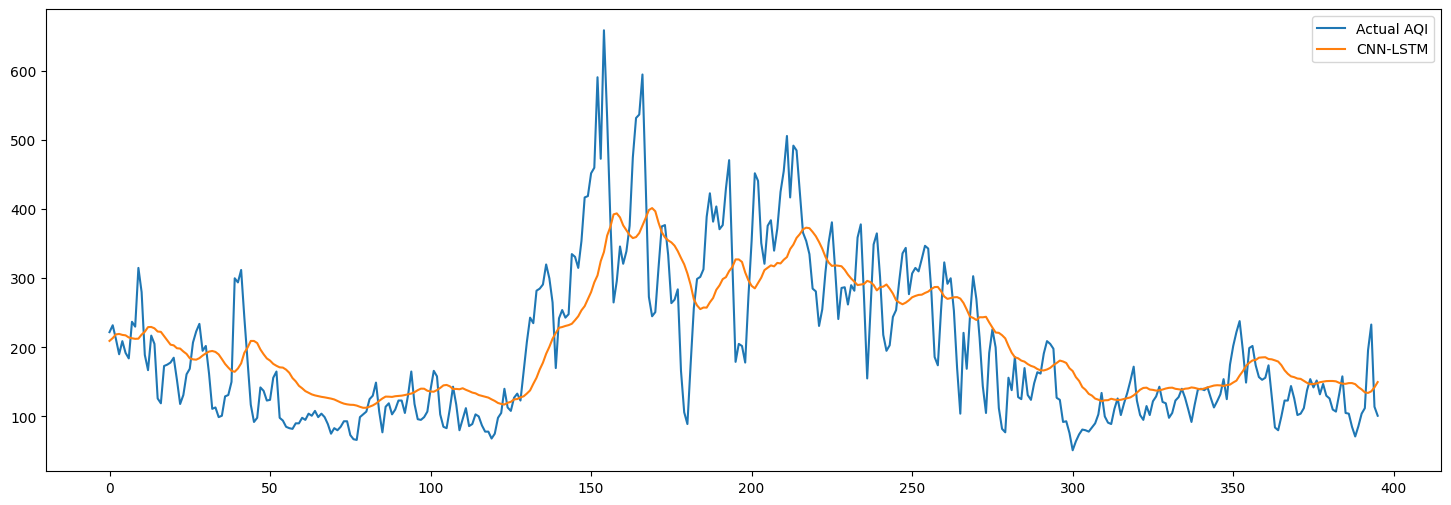

In [ ]:
plt.figure(figsize=(18,6))

plt.plot(y_actual, label="Actual AQI")

plt.plot(cnn_prediction, label="CNN-LSTM")

plt.legend()

plt.show()

In [ ]:
cnn_lstm.save("AQI_CNN_LSTM.keras")

In [ ]:
bi_lstm = Sequential()

bi_lstm.add(
    Bidirectional(
        LSTM(
            128,
            return_sequences=True
        ),
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

bi_lstm.add(Dropout(0.3))

bi_lstm.add(
    Bidirectional(
        LSTM(64)
    )
)

bi_lstm.add(Dropout(0.3))

bi_lstm.add(Dense(32, activation="relu"))

bi_lstm.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
bi_lstm.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

In [ ]:
bi_history = bi_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0217 - mae: 0.1102 - val_loss: 0.0105 - val_mae: 0.0742
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0114 - mae: 0.0841 - val_loss: 0.0084 - val_mae: 0.0675
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0103 - mae: 0.0778 - val_loss: 0.0078 - val_mae: 0.0625
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0097 - mae: 0.0752 - val_loss: 0.0076 - val_mae: 0.0616
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0095 - mae: 0.0746 - val_loss: 0.0080 - val_mae: 0.0659
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0085 - mae: 0.0712 - val_loss: 0.0065 - val_mae: 0.0577
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0084 - mae: 0.0707 - val_loss: 0.0062 - val_mae: 0.0562
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0079 - mae: 0.0681 - val_loss: 0.0061 - val_mae: 0.0571
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - lo

In [ ]:
bi_prediction = bi_lstm.predict(X_test)

bi_prediction = scaler.inverse_transform(bi_prediction)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


In [ ]:
bi_mae = mean_absolute_error(y_actual, bi_prediction)

bi_mse = mean_squared_error(y_actual, bi_prediction)

bi_rmse = np.sqrt(bi_mse)

bi_r2 = r2_score(y_actual, bi_prediction)

print("MAE :", bi_mae)
print("RMSE :", bi_rmse)
print("R2 :", bi_r2)

MAE : 50.97030342949761
RMSE : 70.29083769049583
R2 : 0.6203774637501789


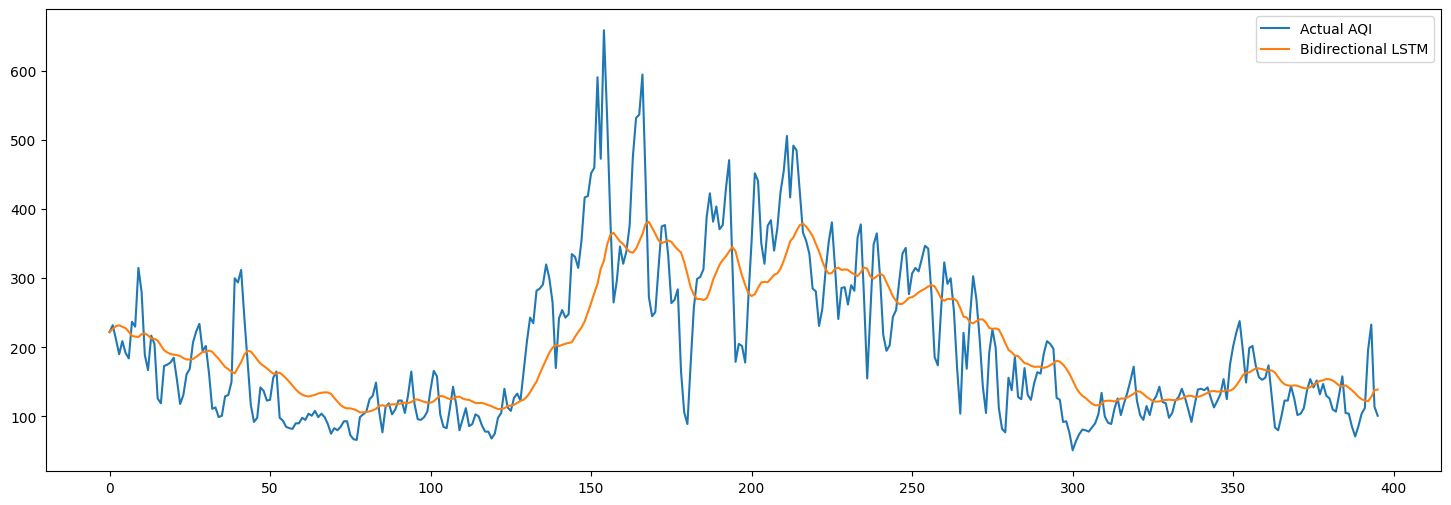

In [ ]:
plt.figure(figsize=(18,6))

plt.plot(y_actual, label="Actual AQI")

plt.plot(bi_prediction, label="Bidirectional LSTM")

plt.legend()

plt.show()

In [ ]:
bi_lstm.save("AQI_Bidirectional_LSTM.keras")

In [ ]:
gru_model = Sequential()

gru_model.add(
    GRU(
        128,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

gru_model.add(Dropout(0.3))

gru_model.add(GRU(64))

gru_model.add(Dropout(0.3))

gru_model.add(Dense(32, activation="relu"))

gru_model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
gru_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

In [ ]:
gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0336 - mae: 0.1330 - val_loss: 0.0098 - val_mae: 0.0791
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0110 - mae: 0.0801 - val_loss: 0.0087 - val_mae: 0.0700
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0097 - mae: 0.0767 - val_loss: 0.0069 - val_mae: 0.0602
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0096 - mae: 0.0759 - val_loss: 0.0065 - val_mae: 0.0593
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0085 - mae: 0.0709 - val_loss: 0.0062 - val_mae: 0.0585
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0083 - mae: 0.0698 - val_loss: 0.0055 - val_mae: 0.0550
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0077 - mae: 0.0682 - val_loss: 0.0052 - val_mae: 0.0551
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0071 - mae: 0.0647 - val_loss: 0.0047 - val_mae: 0.0506
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - lo

In [ ]:
gru_prediction = gru_model.predict(X_test)

gru_prediction = scaler.inverse_transform(gru_prediction)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [ ]:
gru_mae = mean_absolute_error(y_actual, gru_prediction)

gru_mse = mean_squared_error(y_actual, gru_prediction)

gru_rmse = np.sqrt(gru_mse)

gru_r2 = r2_score(y_actual, gru_prediction)

print("MAE :", gru_mae)
print("RMSE :", gru_rmse)
print("R2 :", gru_r2)

MAE : 54.35115802649295
RMSE : 68.0080460305399
R2 : 0.6446345984694561


In [ ]:
gru_model.save("AQI_GRU.keras")

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "LSTM",
        "CNN-LSTM",
        "Bidirectional LSTM",
        "GRU"
    ],
    "MAE": [
        mae,
        cnn_mae,
        bi_mae,
        gru_mae
    ],
    "RMSE": [
        rmse,
        cnn_rmse,
        bi_rmse,
        gru_rmse
    ],
    "R2 Score": [
        r2,
        cnn_r2,
        bi_r2,
        gru_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,LSTM,32.049041,44.323477,0.849054
1,CNN-LSTM,54.349572,72.108588,0.600489
2,Bidirectional LSTM,50.970303,70.290838,0.620377
3,GRU,54.351158,68.008046,0.644635


In [ ]:
best_model = comparison.sort_values(
    by="RMSE",
    ascending=True
)

best_model

,Model,MAE,RMSE,R2 Score
0,LSTM,32.049041,44.323477,0.849054
3,GRU,54.351158,68.008046,0.644635
2,Bidirectional LSTM,50.970303,70.290838,0.620377
1,CNN-LSTM,54.349572,72.108588,0.600489


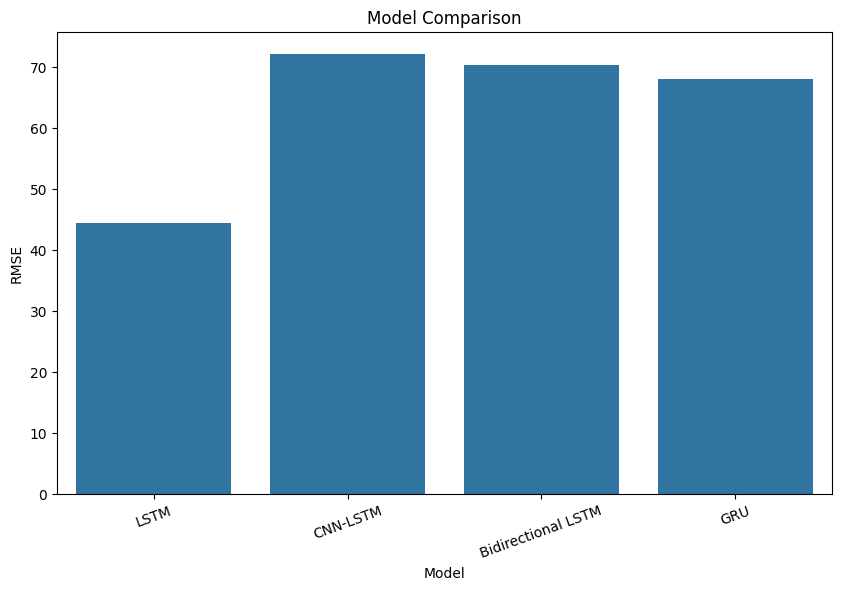

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Model",
    y="RMSE",
    data=comparison
)

plt.xticks(rotation=20)

plt.title("Model Comparison")

plt.show()

In [ ]:
comparison.to_csv(
    "Model_Comparison.csv",
    index=False
)

In [ ]:
def forecast_future(model, data, days):

    temp = data[-30:].copy()

    predictions = []

    for i in range(days):

        x = temp.reshape(1,30,1)

        pred = model.predict(
            x,
            verbose=0
        )

        predictions.append(pred[0][0])

        temp = np.append(
            temp[1:],
            pred
        )

    return np.array(predictions)

In [ ]:
future = forecast_future(
    model=tf.keras.models.load_model("best_lstm.keras"),
    data=scaled_data,
    days=30
)

In [ ]:
future = scaler.inverse_transform(
    future.reshape(-1,1)
)

In [ ]:
forecast = pd.DataFrame({
    "Day": np.arange(1,31),
    "Predicted AQI": future.flatten()
})

forecast

,Day,Predicted AQI
0,1,108.572929
1,2,110.351707
2,3,111.230278
3,4,111.434250
4,5,111.282646
5,6,111.003685
6,7,110.702522
7,8,110.379272
8,9,110.059891
9,10,109.750938


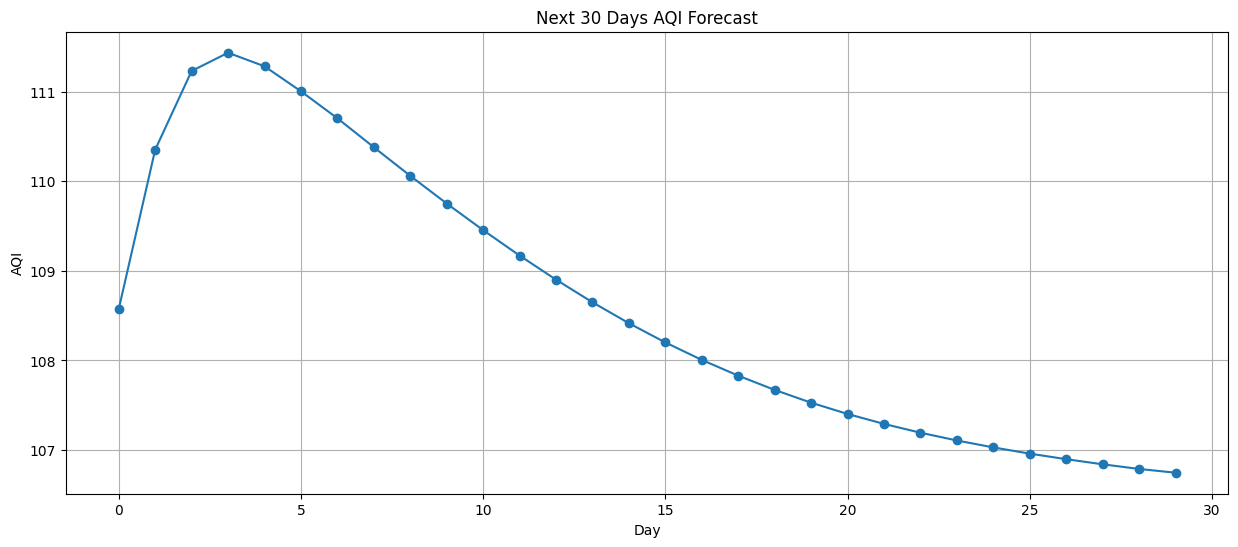

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    forecast["Predicted AQI"],
    marker="o"
)

plt.title("Next 30 Days AQI Forecast")

plt.xlabel("Day")

plt.ylabel("AQI")

plt.grid()

plt.show()

In [ ]:
forecast.to_csv(
    "AQI_30_Days_Forecast.csv",
    index=False
)

In [ ]:
from google.colab import files

# Ensure files are written to disk before downloading
forecast.to_csv('AQI_30_Days_Forecast.csv', index=False)
comparison.to_csv('Model_Comparison.csv', index=False)

# Download the files
files.download('AQI_30_Days_Forecast.csv')
files.download('Model_Comparison.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install -q streamlit
import streamlit as st
import pandas as pd
import numpy as np
import tensorflow as tf
import plotly.express as px

st.set_page_config(
    page_title="AQI Prediction System",
    layout="wide"
)

st.title("Air Quality Prediction System")

model = tf.keras.models.load_model("best_lstm.keras")

df = pd.read_csv("Clean_AQI_Dataset.csv")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 121.0 MB/s eta 0:00:00


2026-07-09 04:51:51.400 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:51:51.401 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:51:51.723 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-09 04:51:51.724 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:51:51.726 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
st.subheader("Dataset Preview")

st.dataframe(df.head())

2026-07-09 04:55:12.473 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:55:12.477 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:55:12.478 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:55:12.559 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:55:12.561 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:55:12.562 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:55:12.563 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
st.subheader("AQI Distribution")

fig = px.histogram(
    df,
    x="AQI",
    nbins=40
)

st.plotly_chart(fig)

2026-07-09 04:55:40.165 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:55:40.167 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:55:40.171 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:55:40.921 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:55:40.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:55:40.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:55:40.926 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:55:40.926 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [ ]:
city = st.selectbox(
    "Select City",
    sorted(df["City"].unique())
)

city_df = df[df["City"] == city]

st.line_chart(
    city_df.set_index("Date")["AQI"]
)

2026-07-09 04:57:38.565 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:57:38.569 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:57:38.571 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:57:38.576 Session state does not function when running a script without `streamlit run`
2026-07-09 04:57:38.581 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:57:38.583 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:57:38.585 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:57:41.927 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:57

DeltaGenerator()

In [ ]:
comparison = pd.read_csv("Model_Comparison.csv")

st.subheader("Model Comparison")

st.dataframe(comparison)

2026-07-09 04:58:01.737 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:58:01.738 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:58:01.740 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:58:01.743 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:58:01.744 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:58:01.746 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:58:01.746 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
forecast = pd.read_csv(
    "AQI_30_Days_Forecast.csv"
)

st.subheader("30 Days Forecast")

st.line_chart(
    forecast["Predicted AQI"]
)

2026-07-09 04:58:30.411 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:58:30.413 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:58:30.414 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:58:30.470 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:58:30.471 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:58:30.472 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
st.success("Prediction System Ready")

2026-07-09 04:58:49.532 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:58:49.533 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:58:49.535 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()